Epoch 001 | Acc=0.501 | Φ*=0.000000
Epoch 002 | Acc=0.499 | Φ*=0.000000
Epoch 003 | Acc=0.499 | Φ*=0.000000
Epoch 004 | Acc=0.499 | Φ*=0.160286
Epoch 005 | Acc=0.501 | Φ*=0.000000
Epoch 006 | Acc=0.494 | Φ*=0.048883
Epoch 007 | Acc=0.499 | Φ*=0.000000
Epoch 008 | Acc=0.500 | Φ*=0.079604
Epoch 009 | Acc=0.501 | Φ*=0.061602
Epoch 010 | Acc=0.501 | Φ*=0.000000
Epoch 011 | Acc=0.507 | Φ*=0.027220
Epoch 012 | Acc=0.503 | Φ*=0.000000
Epoch 013 | Acc=0.512 | Φ*=0.000000
Epoch 014 | Acc=0.499 | Φ*=0.000000
Epoch 015 | Acc=0.502 | Φ*=0.000000
Epoch 016 | Acc=0.497 | Φ*=0.000000
Epoch 017 | Acc=0.506 | Φ*=0.000000
Epoch 018 | Acc=0.506 | Φ*=0.000000
Epoch 019 | Acc=0.514 | Φ*=0.069669
Epoch 020 | Acc=0.520 | Φ*=0.113815
Epoch 021 | Acc=0.501 | Φ*=0.200521
Epoch 022 | Acc=0.510 | Φ*=0.051354
Epoch 023 | Acc=0.528 | Φ*=1.271561
Epoch 024 | Acc=0.554 | Φ*=5.184833
Epoch 025 | Acc=0.508 | Φ*=2.367902
Epoch 026 | Acc=0.548 | Φ*=7.133826
Epoch 027 | Acc=0.496 | Φ*=9.287786
Epoch 028 | Acc=0.576 | Φ*=6

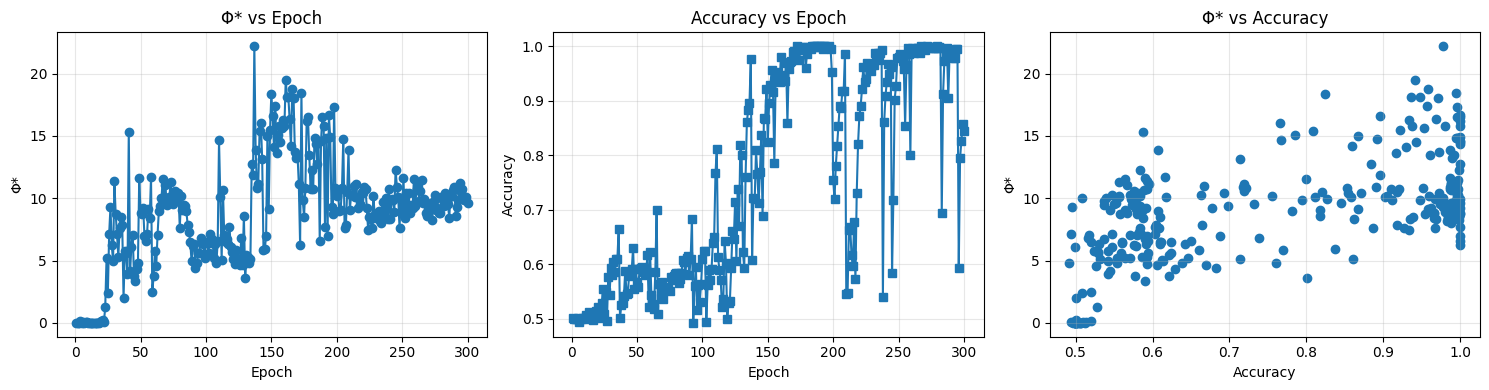

CSV files saved in: /content/phi_results


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ===============================
# CONFIGURATION
# ===============================
device = "cpu"
HIDDEN_SIZE = 60
EPOCHS = 300
BATCH_SIZE = 32
LR = 0.001
MAX_N = 8

# ===============================
# Φ* CONFIG
# ===============================
@dataclass
class PhiConfig:
    tau: int = 1
    n_partitions_sample: int = 20

# ===============================
# DATASET
# ===============================
symbol_to_idx = {'X':0,'Y':1,'A':2,'B':3,'EOS':4}

def generate_sequence():
    valid = np.random.rand() > 0.5
    rule = np.random.choice(['X','Y'])
    n = np.random.randint(1, MAX_N+1)

    seq = [rule] + ['A'] * n
    if rule == 'X':
        seq += ['B'] * (n if valid else n+np.random.choice([-1,1]))
    else:
        seq += ['B'] * (2*n if valid else 2*n+np.random.choice([-1,1]))

    seq.append('EOS')
    onehot = np.eye(5)[[symbol_to_idx[s] for s in seq]]
    return onehot, float(valid)

class GrammarDataset(Dataset):
    def __init__(self, n_samples=3000):
        self.data = [generate_sequence() for _ in range(n_samples)]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x,dtype=torch.float32), torch.tensor(y)

def collate(batch):
    xs, ys = zip(*batch)
    max_len = max(x.shape[0] for x in xs)
    padded = []
    for x in xs:
        pad = torch.zeros(max_len-x.shape[0],5)
        padded.append(torch.cat([x,pad],0))
    return torch.stack(padded), torch.tensor(ys)

# ===============================
# LSTM MODEL
# ===============================
class GrammarLSTM(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(5, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, c) = self.lstm(x)
        return torch.sigmoid(self.fc(h.squeeze(0))), h

# ===============================
# HIDDEN STATE COLLECTION
# ===============================
def collect_hidden_states_lstm(model, n_samples=2000):
    states = []
    h, c = None, None

    with torch.no_grad():
        for _ in range(n_samples):
            x = torch.eye(5)[np.random.randint(0,5)].view(1,1,-1)
            _, (h, c) = model.lstm(x, (h, c) if h is not None else None)
            states.append(h.squeeze().cpu().numpy())

    return np.array(states)

# ===============================
# BARRETT & SETH Φ*
# ===============================
class BarrettSethPhiStar:
    def __init__(self, config):
        self.config = config

    def gaussian_mi(self, X, Y):
        n = X.shape[1]
        reg = 1e-6 * np.eye(n)

        Cov_X = np.cov(X.T) + reg
        Cov_Y = np.cov(Y.T) + reg
        Cov_XY = np.cov(np.hstack([X, Y]).T) + 1e-6 * np.eye(2*n)

        sx, logdet_x = np.linalg.slogdet(Cov_X)
        sy, logdet_y = np.linalg.slogdet(Cov_Y)
        sxy, logdet_xy = np.linalg.slogdet(Cov_XY)

        if sx <= 0 or sy <= 0 or sxy <= 0:
            return 0.0

        return 0.5 * (logdet_x + logdet_y - logdet_xy) / np.log(2)

    def estimate(self, states):
        X = states[:-self.config.tau]
        Y = states[self.config.tau:]

        I_whole = self.gaussian_mi(X, Y)
        if I_whole <= 0:
            return 0.0

        n_dim = X.shape[1]
        nodes = np.arange(n_dim)
        min_I = np.inf

        for _ in range(self.config.n_partitions_sample):
            k = np.random.randint(1, n_dim//2 + 1)
            A = np.random.choice(nodes, k, replace=False)
            B = np.setdiff1d(nodes, A)

            if len(B) == 0:
                continue

            I_A = self.gaussian_mi(X[:,A], Y[:,A])
            I_B = self.gaussian_mi(X[:,B], Y[:,B])
            min_I = min(min_I, I_A + I_B)

        return max(I_whole - min_I, 0.0)

# ===============================
# TRAINING LOOP WITH Φ*
# ===============================
def train_with_phi_tracking(config, phi_samples_per_epoch=500):

    model = GrammarLSTM(HIDDEN_SIZE).to(device)
    loader = DataLoader(GrammarDataset(), batch_size=BATCH_SIZE,
                        shuffle=True, collate_fn=collate)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()
    phi_estimator = BarrettSethPhiStar(config)

    phi_history, acc_history = [], []

    for epoch in range(1, EPOCHS+1):

        model.train()
        for x,y in loader:
            optimizer.zero_grad()
            pred,_ = model(x)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct,total = 0,0
        with torch.no_grad():
            for x,y in loader:
                pred,_ = model(x)
                pred = (pred.squeeze()>0.5).float()
                correct += (pred==y).sum().item()
                total += y.size(0)

        acc = correct/total
        acc_history.append(acc)

        states = collect_hidden_states_lstm(model, phi_samples_per_epoch)
        phi = phi_estimator.estimate(states)
        phi_history.append(phi)

        print(f"Epoch {epoch:03d} | Acc={acc:.3f} | Φ*={phi:.6f}")

    return phi_history, acc_history

# ===============================
# VISUALIZATION
# ===============================
def plot_results(phi, acc):
    epochs = np.arange(1, len(phi)+1)

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, phi, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Epoch")
    plt.grid(alpha=0.3)

    plt.subplot(1,3,2)
    plt.plot(epochs, acc, marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epoch")
    plt.grid(alpha=0.3)

    plt.subplot(1,3,3)
    plt.scatter(acc, phi)
    plt.xlabel("Accuracy")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Accuracy")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ===============================
# MAIN
# ===============================
if __name__ == "__main__":

    config = PhiConfig(
        tau=1,
        n_partitions_sample=20
    )

    phi_hist, acc_hist = train_with_phi_tracking(
        config,
        phi_samples_per_epoch=500
    )

    plot_results(phi_hist, acc_hist)
import os
import pandas as pd
import numpy as np

# -------------------------------
# SAVE DIRECTORY (Colab)
# -------------------------------
SAVE_DIR = "/content/phi_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# SAVE CSV FILES
# -------------------------------
def save_results_to_csv(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history) + 1)

    # ---- Φ vs Epoch ----
    df_phi_epoch = pd.DataFrame({
        "epoch": epochs,
        "phi": phi_history
    })
    df_phi_epoch.to_csv(f"{SAVE_DIR}/phi_vs_epoch.csv", index=False)

    # ---- Accuracy vs Epoch ----
    df_acc_epoch = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history
    })
    df_acc_epoch.to_csv(f"{SAVE_DIR}/accuracy_vs_epoch.csv", index=False)

    # ---- Φ vs Accuracy ----
    df_phi_acc = pd.DataFrame({
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_phi_acc.to_csv(f"{SAVE_DIR}/phi_vs_accuracy.csv", index=False)

    # ---- Combined ----
    df_full = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_full.to_csv(f"{SAVE_DIR}/training_summary.csv", index=False)

    print("CSV files saved in:", SAVE_DIR)

save_results_to_csv(phi_hist, acc_hist)




In [ ]:
print(max(phi_hist))


22.201863389681478


Using device: cpu
Seq2Seq Translation with Φ* Tracking

1. Building vocabularies...
Source vocab size: 4
Target vocab size: 4

2. Creating datasets...

3. Initializing Seq2Seq model...
Model has 100,612 trainable parameters

4. Initializing Φ* estimator...

5. Training model with Φ* tracking...
Epoch 001 | Train Loss: 0.4746 | Val Loss: 0.2881 | Φ*: 2.370816
Epoch 002 | Train Loss: 0.2418 | Val Loss: 0.2457 | Φ*: 2.706662
Epoch 003 | Train Loss: 0.2330 | Val Loss: 0.2349 | Φ*: 2.886277
Epoch 004 | Train Loss: 0.2270 | Val Loss: 0.2490 | Φ*: 2.853232
Epoch 005 | Train Loss: 0.2249 | Val Loss: 0.2338 | Φ*: 2.594757
Epoch 006 | Train Loss: 0.2190 | Val Loss: 0.2364 | Φ*: 3.077317
Epoch 007 | Train Loss: 0.2173 | Val Loss: 0.2469 | Φ*: 2.932120
Epoch 008 | Train Loss: 0.2153 | Val Loss: 0.2106 | Φ*: 3.048912
Epoch 009 | Train Loss: 0.2139 | Val Loss: 0.2340 | Φ*: 3.314062
Epoch 010 | Train Loss: 0.2141 | Val Loss: 0.2264 | Φ*: 2.911896
Epoch 011 | Train Loss: 0.2106 | Val Loss: 0.2284 | Φ*

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/phi_translation_results.png'

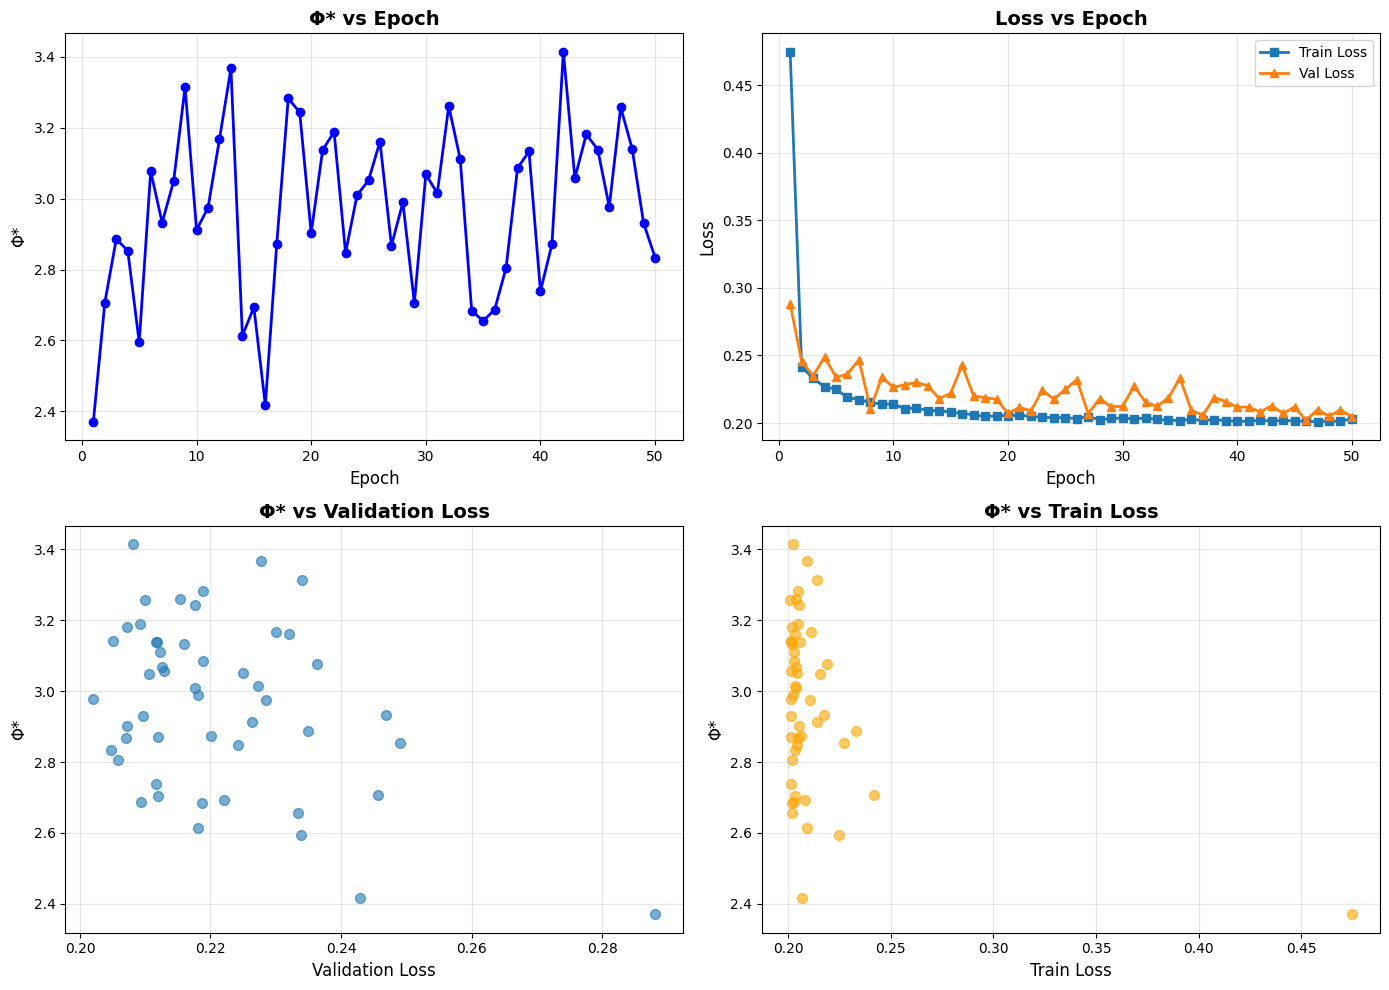

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import Counter
import random
from typing import List, Tuple

# ===============================
# CONFIGURATION
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

HIDDEN_SIZE = 64
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.001
MAX_LEN = 50
MIN_FREQ = 2
TEACHER_FORCING_RATIO = 0.5

# ===============================
# Φ* CONFIG
# ===============================
@dataclass
class PhiConfig:
    tau: int = 1
    n_partitions_sample: int = 20

# ===============================
# VOCABULARY
# ===============================
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in sentence:
                frequencies[word] += 1

        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, text):
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in text]

# ===============================
# DATASET - Multi30k Simulation
# ===============================
class TranslationDataset(Dataset):
    """
    Simulated Multi30k-style dataset.
    In practice, you'd load from torchtext or files.
    """
    def __init__(self, src_vocab, trg_vocab, n_samples=3000, split='train'):
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.data = self._generate_synthetic_pairs(n_samples)

    def _generate_synthetic_pairs(self, n_samples):
        """
        Generate synthetic English->German-like pairs
        Real implementation: load from Multi30k dataset
        """
        # Simplified synthetic vocabulary for demonstration
        english_words = ["a", "man", "woman", "child", "dog", "cat", "walks", "runs", "sits",
                        "eats", "sleeps", "in", "the", "park", "house", "street", "quickly", "slowly"]
        german_words = ["ein", "mann", "frau", "kind", "hund", "katze", "geht", "läuft", "sitzt",
                       "isst", "schläft", "in", "der", "dem", "park", "haus", "straße", "schnell", "langsam"]

        pairs = []
        for _ in range(n_samples):
            # Generate English sentence
            length = random.randint(3, 8)
            en_sent = [random.choice(english_words) for _ in range(length)]

            # Generate "translation" (simplified - just random German words)
            de_length = random.randint(max(2, length-1), length+2)
            de_sent = [random.choice(german_words) for _ in range(de_length)]

            pairs.append((en_sent, de_sent))

        return pairs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, trg = self.data[idx]

        src_numericalized = [self.src_vocab.stoi["<SOS>"]] + \
                           self.src_vocab.numericalize(src) + \
                           [self.src_vocab.stoi["<EOS>"]]

        trg_numericalized = [self.trg_vocab.stoi["<SOS>"]] + \
                           self.trg_vocab.numericalize(trg) + \
                           [self.trg_vocab.stoi["<EOS>"]]

        return (torch.tensor(src_numericalized),
                torch.tensor(trg_numericalized))

def collate_fn(batch):
    """Pad sequences in batch to same length"""
    src_batch, trg_batch = [], []

    for src, trg in batch:
        src_batch.append(src)
        trg_batch.append(trg)

    src_batch = pad_sequence(src_batch, padding_value=0, batch_first=True)
    trg_batch = pad_sequence(trg_batch, padding_value=0, batch_first=True)

    return src_batch, trg_batch

# ===============================
# SEQ2SEQ MODEL
# ===============================
class Encoder(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(input_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers,
                           dropout=dropout if num_layers > 1 else 0,
                           batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedding = self.dropout(self.embedding(x))
        # embedding: (batch_size, seq_len, embedding_size)

        outputs, (hidden, cell) = self.lstm(embedding)
        # outputs: (batch_size, seq_len, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)

        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_size, embedding_size, hidden_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(output_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers,
                           dropout=dropout if num_layers > 1 else 0,
                           batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        # x: (batch_size, 1)
        x = x.unsqueeze(1) if x.dim() == 1 else x

        embedding = self.dropout(self.embedding(x))
        # embedding: (batch_size, 1, embedding_size)

        output, (hidden, cell) = self.lstm(embedding, (hidden, cell))
        # output: (batch_size, 1, hidden_size)

        prediction = self.fc(output.squeeze(1))
        # prediction: (batch_size, output_size)

        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (batch_size, src_len)
        # trg: (batch_size, trg_len)

        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(src.device)

        # Encode
        encoder_outputs, hidden, cell = self.encoder(src)

        # First input to decoder is <SOS> token
        input = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1

        return outputs

# ===============================
# HIDDEN STATE COLLECTION
# ===============================
def collect_encoder_hidden_states(encoder, src_vocab, n_samples=2000, max_len=20):
    """
    Collect hidden states from encoder by processing random input sequences
    """
    states = []

    encoder.eval()
    with torch.no_grad():
        for _ in range(n_samples):
            # Generate random sequence
            seq_len = random.randint(3, max_len)
            vocab_size = len(src_vocab)

            # Random tokens (avoiding PAD=0)
            tokens = torch.randint(1, vocab_size, (1, seq_len)).to(device)

            # Get encoder hidden states
            outputs, hidden, cell = encoder(tokens)

            # Take the final hidden state from last layer
            # hidden shape: (num_layers, batch_size=1, hidden_size)
            final_hidden = hidden[-1, 0, :].cpu().numpy()
            states.append(final_hidden)

    return np.array(states)

# ===============================
# BARRETT & SETH Φ*
# ===============================
class BarrettSethPhiStar:
    def __init__(self, config):
        self.config = config

    def gaussian_mi(self, X, Y):
        """Compute mutual information assuming Gaussian distribution"""
        n = X.shape[1]
        reg = 1e-6 * np.eye(n)

        Cov_X = np.cov(X.T) + reg
        Cov_Y = np.cov(Y.T) + reg
        Cov_XY = np.cov(np.hstack([X, Y]).T) + 1e-6 * np.eye(2*n)

        sx, logdet_x = np.linalg.slogdet(Cov_X)
        sy, logdet_y = np.linalg.slogdet(Cov_Y)
        sxy, logdet_xy = np.linalg.slogdet(Cov_XY)

        if sx <= 0 or sy <= 0 or sxy <= 0:
            return 0.0

        return 0.5 * (logdet_x + logdet_y - logdet_xy) / np.log(2)

    def estimate(self, states):
        """Estimate Φ* from state trajectory"""
        if len(states) <= self.config.tau:
            return 0.0

        X = states[:-self.config.tau]
        Y = states[self.config.tau:]

        I_whole = self.gaussian_mi(X, Y)
        if I_whole <= 0:
            return 0.0

        n_dim = X.shape[1]
        nodes = np.arange(n_dim)
        min_I = np.inf

        for _ in range(self.config.n_partitions_sample):
            k = np.random.randint(1, n_dim//2 + 1)
            A = np.random.choice(nodes, k, replace=False)
            B = np.setdiff1d(nodes, A)

            if len(B) == 0:
                continue

            I_A = self.gaussian_mi(X[:, A], Y[:, A])
            I_B = self.gaussian_mi(X[:, B], Y[:, B])
            min_I = min(min_I, I_A + I_B)

        return max(I_whole - min_I, 0.0)

# ===============================
# TRAINING LOOP
# ===============================
def train_epoch(model, iterator, optimizer, criterion, clip=1):
    model.train()
    epoch_loss = 0

    for src, trg in iterator:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio=TEACHER_FORCING_RATIO)

        # output: (batch_size, trg_len, output_dim)
        # trg: (batch_size, trg_len)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in iterator:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0)  # No teacher forcing

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def train_with_phi_tracking(model, train_loader, val_loader, optimizer, criterion,
                            phi_estimator, src_vocab, n_epochs=50, phi_samples=500):

    phi_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate(model, val_loader, criterion)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        # Collect encoder hidden states and compute Φ*
        states = collect_encoder_hidden_states(model.encoder, src_vocab,
                                               n_samples=phi_samples, max_len=20)
        phi = phi_estimator.estimate(states)
        phi_history.append(phi)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Φ*: {phi:.6f}")

    return phi_history, train_loss_history, val_loss_history

# ===============================
# VISUALIZATION
# ===============================
def plot_results(phi, train_loss, val_loss):
    epochs = np.arange(1, len(phi) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Φ* vs Epoch
    axes[0, 0].plot(epochs, phi, marker='o', color='blue', linewidth=2)
    axes[0, 0].set_xlabel("Epoch", fontsize=12)
    axes[0, 0].set_ylabel("Φ*", fontsize=12)
    axes[0, 0].set_title("Φ* vs Epoch", fontsize=14, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)

    # Loss vs Epoch
    axes[0, 1].plot(epochs, train_loss, marker='s', label='Train Loss', linewidth=2)
    axes[0, 1].plot(epochs, val_loss, marker='^', label='Val Loss', linewidth=2)
    axes[0, 1].set_xlabel("Epoch", fontsize=12)
    axes[0, 1].set_ylabel("Loss", fontsize=12)
    axes[0, 1].set_title("Loss vs Epoch", fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Φ* vs Validation Loss
    axes[1, 0].scatter(val_loss, phi, alpha=0.6, s=50)
    axes[1, 0].set_xlabel("Validation Loss", fontsize=12)
    axes[1, 0].set_ylabel("Φ*", fontsize=12)
    axes[1, 0].set_title("Φ* vs Validation Loss", fontsize=14, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

    # Φ* vs Train Loss
    axes[1, 1].scatter(train_loss, phi, alpha=0.6, s=50, color='orange')
    axes[1, 1].set_xlabel("Train Loss", fontsize=12)
    axes[1, 1].set_ylabel("Φ*", fontsize=12)
    axes[1, 1].set_title("Φ* vs Train Loss", fontsize=14, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/home/claude/phi_translation_results.png', dpi=300, bbox_inches='tight')
    print("Plot saved to /home/claude/phi_translation_results.png")
    plt.show()

# ===============================
# MAIN
# ===============================
def main():
    print("="*60)
    print("Seq2Seq Translation with Φ* Tracking")
    print("="*60)

    # Initialize vocabularies
    print("\n1. Building vocabularies...")
    src_vocab = Vocabulary(freq_threshold=MIN_FREQ)
    trg_vocab = Vocabulary(freq_threshold=MIN_FREQ)

    # Create dummy data to build vocab
    dummy_src = [["a", "man", "walks"], ["the", "dog", "runs"]]
    dummy_trg = [["ein", "mann", "geht"], ["der", "hund", "läuft"]]
    src_vocab.build_vocabulary(dummy_src)
    trg_vocab.build_vocabulary(dummy_trg)

    print(f"Source vocab size: {len(src_vocab)}")
    print(f"Target vocab size: {len(trg_vocab)}")

    # Create datasets
    print("\n2. Creating datasets...")
    train_dataset = TranslationDataset(src_vocab, trg_vocab, n_samples=2000, split='train')
    val_dataset = TranslationDataset(src_vocab, trg_vocab, n_samples=500, split='val')

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn)

    # Initialize model
    print("\n3. Initializing Seq2Seq model...")
    INPUT_DIM = len(src_vocab)
    OUTPUT_DIM = len(trg_vocab)
    ENC_EMB_DIM = 128
    DEC_EMB_DIM = 128
    NUM_LAYERS = 1
    DROPOUT = 0.5

    encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
    decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
    model = Seq2Seq(encoder, decoder).to(device)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model has {total_params:,} trainable parameters")

    # Initialize optimizer and loss
    optimizer = optim.Adam(model.parameters(), lr=LR)
    PAD_IDX = trg_vocab.stoi["<PAD>"]
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    # Initialize Φ* estimator
    print("\n4. Initializing Φ* estimator...")
    phi_config = PhiConfig(tau=1, n_partitions_sample=20)
    phi_estimator = BarrettSethPhiStar(phi_config)

    # Train model
    print("\n5. Training model with Φ* tracking...")
    print("="*60)

    phi_hist, train_loss_hist, val_loss_hist = train_with_phi_tracking(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        phi_estimator=phi_estimator,
        src_vocab=src_vocab,
        n_epochs=EPOCHS,
        phi_samples=500
    )

    # Plot results
    print("\n6. Generating plots...")
    plot_results(phi_hist, train_loss_hist, val_loss_hist)

    # Save results
    print("\n7. Saving results...")
    results = {
        'phi': phi_hist,
        'train_loss': train_loss_hist,
        'val_loss': val_loss_hist
    }
    np.save('/home/claude/phi_translation_results.npy', results)
    print("Results saved to /home/claude/phi_translation_results.npy")

    print("\n" + "="*60)
    print("Training complete!")
    print("="*60)

    return model, phi_hist, train_loss_hist, val_loss_hist

if __name__ == "__main__":
    # Set random seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    model, phi_hist, train_loss_hist, val_loss_hist = main()